In [1]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Key takeaways:

- Most variables are weakly to moderately correlated; no evidence of problematic multicollinearity among main predictors.
- Socioeconomic disadvantage and land area exposure are not strongly linked to funding or insurance uptake at the bivariate level.
- Insurance claims paid and funding are most closely linked, suggesting funding allocation is partly reactive to past losses.
- Data is highly skewed with outliers, especially for funding and claims. Log transformations are used where appropriate.

In [2]:
# open df
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")

In [3]:
# show shape and head of df
print(df.shape)
display(df.head())

(256, 77)


,GEOID,town_name,aland_sqm,awater_sqm,town_area_sqm,pct_river_corridor,pct_high_risk_NFHL,nfhl_covered_flag,median_income,median_income_moe,...,share_infrastructure_protection,share_infrastructure_stormwater,share_other,share_planning,share_structure_protection,funding_per_capita,log_funding_per_capita,funding_per_occupied_unit,log_funding_per_occupied_unit,has_funding
0,5000100325,Addison town,107710362,19168382,126878736.0,3.202944,0.000000,0,106667.0,7181.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,5001900475,Albany town,99830311,1135549,100965867.0,3.686352,0.000000,0,59167.0,13730.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,5001300860,Alburgh town,75373352,47562250,122935601.0,0.266919,0.000000,0,76429.0,22453.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,5002701300,Andover town,74720639,149987,74870626.0,1.920218,0.667693,1,102500.0,37746.0,...,0.000000,0.0,0.0,0.0,0.000000,235.852571,5.467438,610.441949,6.41582,True
4,5000301450,Arlington town,108847993,491791,109339770.0,4.521668,4.365822,1,102308.0,10759.0,...,0.333333,0.0,0.0,0.0,0.333333,5.165386,1.818951,15.532028,2.80530,True


In [4]:
# Show variable types, missing data, and summary statistics.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 77 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   GEOID                              256 non-null    int64  
 1   town_name                          256 non-null    object 
 2   aland_sqm                          256 non-null    int64  
 3   awater_sqm                         256 non-null    int64  
 4   town_area_sqm                      256 non-null    float64
 5   pct_river_corridor                 256 non-null    float64
 6   pct_high_risk_NFHL                 256 non-null    float64
 7   nfhl_covered_flag                  256 non-null    int64  
 8   median_income                      247 non-null    float64
 9   median_income_moe                  247 non-null    float64
 10  total_population                   256 non-null    int64  
 11  total_population_moe               256 non-null    int64  

In [5]:
# list of key variables to focus on in EDA
key_vars = [
    "pct_river_corridor",
    "pct_high_risk_NFHL",
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]

In [6]:
# display summary statistics for key variables
df[key_vars].describe()

,pct_river_corridor,pct_high_risk_NFHL,median_income,percent_elderly,median_year_house_built,pct_no_vehicle,pct_renter_occupied,pct_bachelors_or_higher,pct_below_poverty,percent_with_disability,pct_mobile_home,funding_per_capita,log_funding_per_capita,funding_per_occupied_unit,log_funding_per_occupied_unit,claims_paid_per_capita,current_insurance_penetration
count,256.000000,256.000000,247.000000,250.000000,246.000000,250.000000,250.000000,250.000000,250.000000,250.000000,253.000000,125.000000,125.000000,125.000000,125.000000,160.000000,204.000000
mean,3.512886,2.522234,83173.882591,23.954418,1976.247967,3.847993,16.858868,40.353394,9.257860,14.124559,7.621536,319.348988,4.659703,731.361742,5.463106,241.919830,0.018288
std,2.510260,3.828191,21126.809304,7.644226,9.227703,3.597151,11.119974,13.818691,7.538466,5.093181,6.278553,490.864270,1.793954,1081.276173,1.894918,472.592185,0.023325
min,0.000000,0.000000,13849.000000,6.706793,1944.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000731
25%,1.921324,0.000000,70129.500000,19.638082,1972.250000,1.124784,8.720938,31.115559,5.280003,10.703939,3.001200,28.929119,3.398832,73.922601,4.316456,9.575629,0.005800
50%,2.985074,0.672513,80250.000000,22.813505,1977.500000,2.914307,15.097505,37.939715,8.173765,13.610944,6.144465,137.328686,4.929633,317.168058,5.762580,49.984322,0.011116
75%,4.311916,3.517033,94693.000000,27.487627,1982.000000,5.644247,21.024247,48.829313,11.609086,16.518165,10.443686,346.928271,5.851996,849.576786,6.745915,198.654168,0.024532
max,20.139475,22.009892,195938.000000,73.684211,2001.000000,17.603598,64.797660,91.208791,91.176471,34.666667,31.347962,3021.403172,8.013808,5959.924960,8.692981,2845.690388,0.239829


In [7]:
# show missing data for key variables
df[key_vars].isnull().sum()

pct_river_corridor                 0
pct_high_risk_NFHL                 0
median_income                      9
percent_elderly                    6
median_year_house_built           10
pct_no_vehicle                     6
pct_renter_occupied                6
pct_bachelors_or_higher            6
pct_below_poverty                  6
percent_with_disability            6
pct_mobile_home                    3
funding_per_capita               131
log_funding_per_capita           131
funding_per_occupied_unit        131
log_funding_per_occupied_unit    131
claims_paid_per_capita            96
current_insurance_penetration     52
dtype: int64

Lotta tails follow. To be expected.

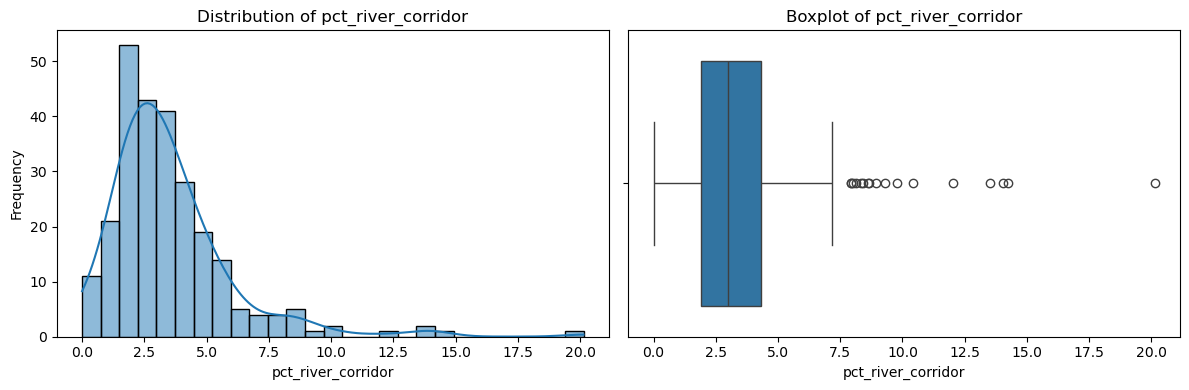

Skewness of pct_river_corridor: 2.4697920923443912


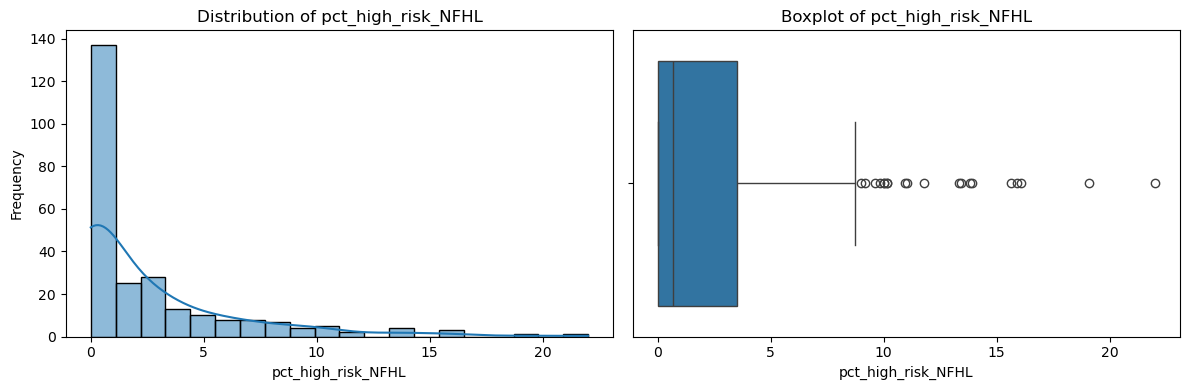

Skewness of pct_high_risk_NFHL: 2.119303961985999


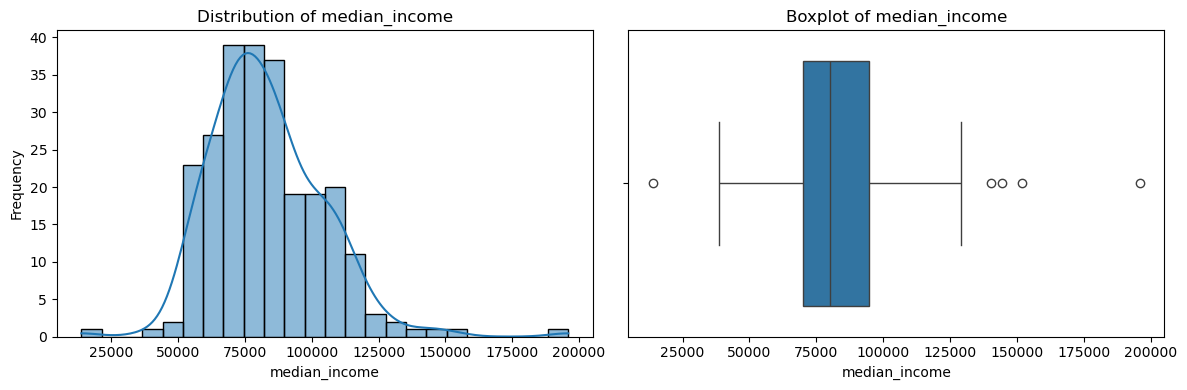

Skewness of median_income: 0.9243938865890698


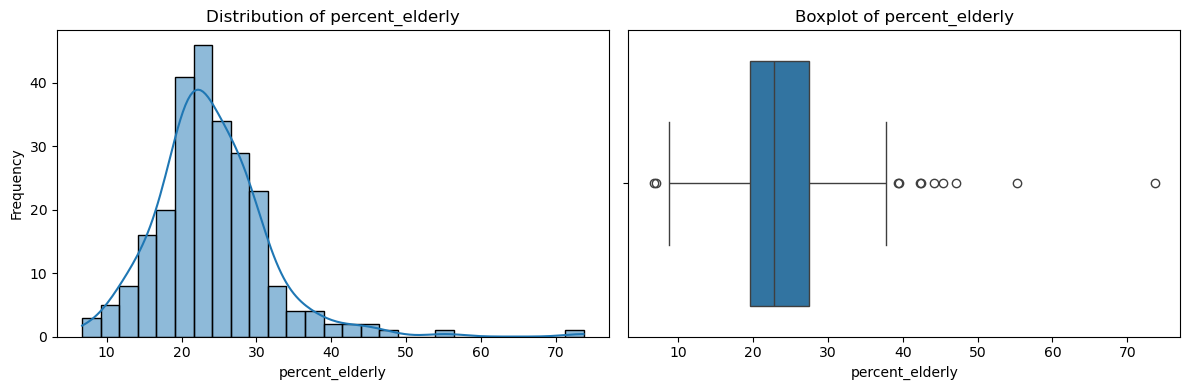

Skewness of percent_elderly: 1.6222988127759623


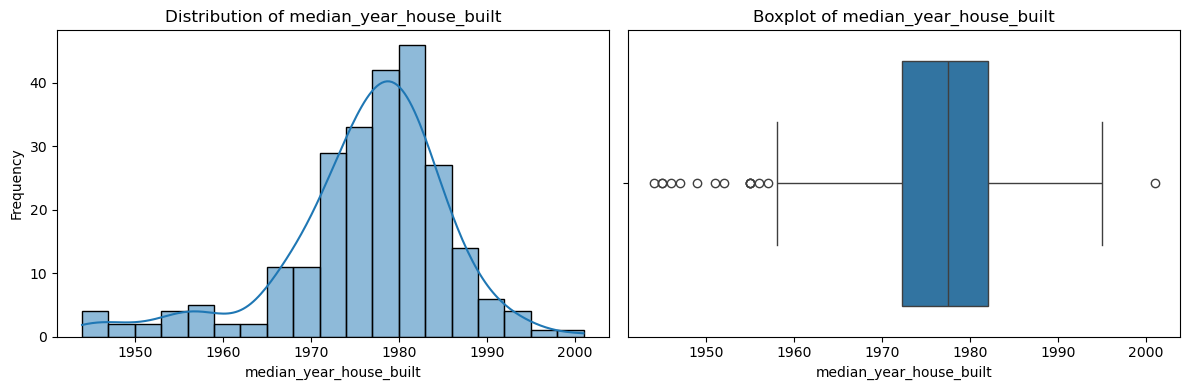

Skewness of median_year_house_built: -1.114547131355426


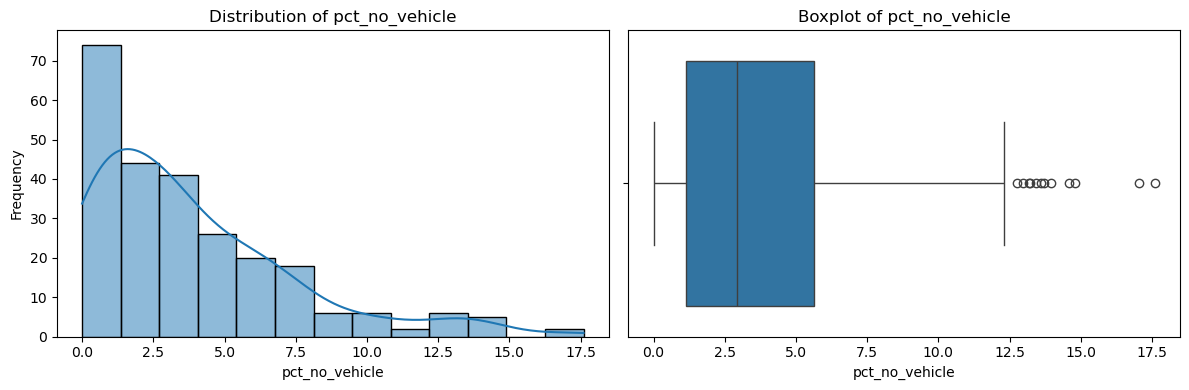

Skewness of pct_no_vehicle: 1.3964799861854658


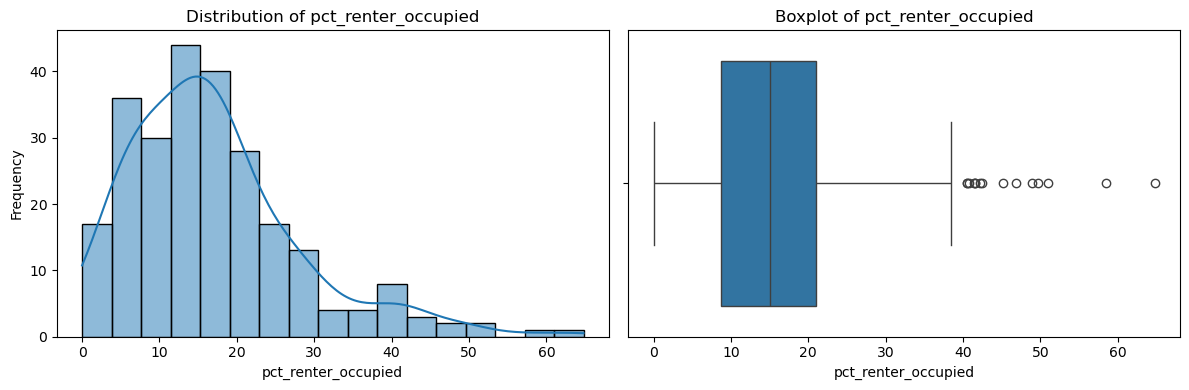

Skewness of pct_renter_occupied: 1.2528103476080978


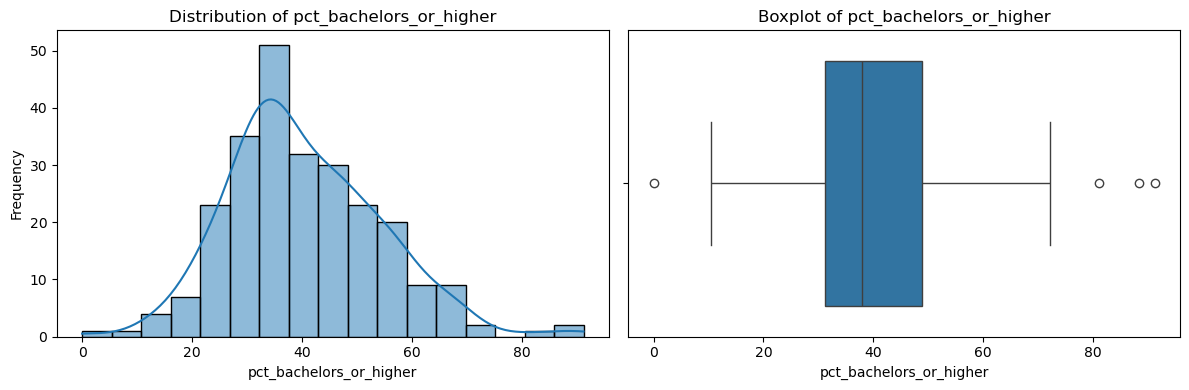

Skewness of pct_bachelors_or_higher: 0.5321044877100725


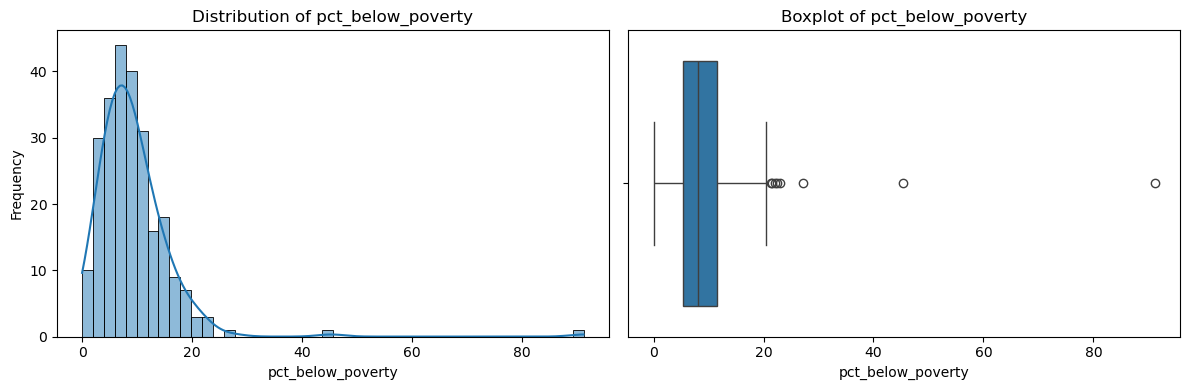

Skewness of pct_below_poverty: 5.775772763945157


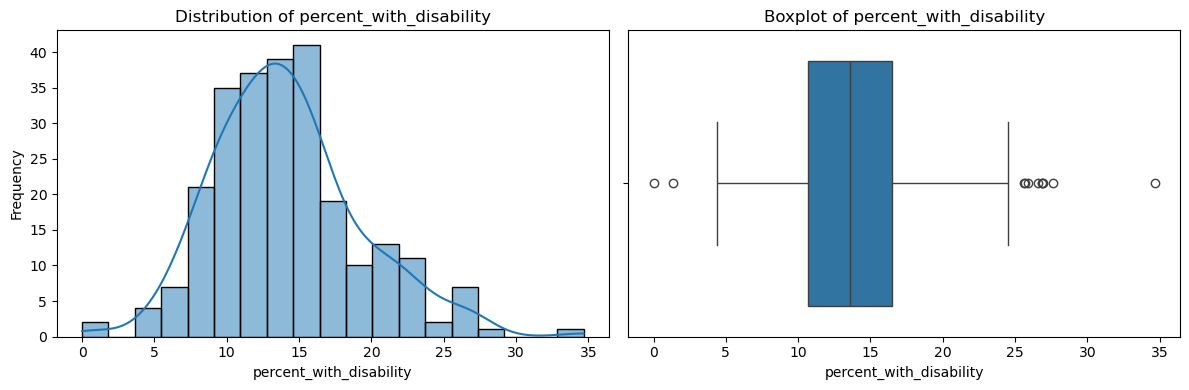

Skewness of percent_with_disability: 0.6194403059336864


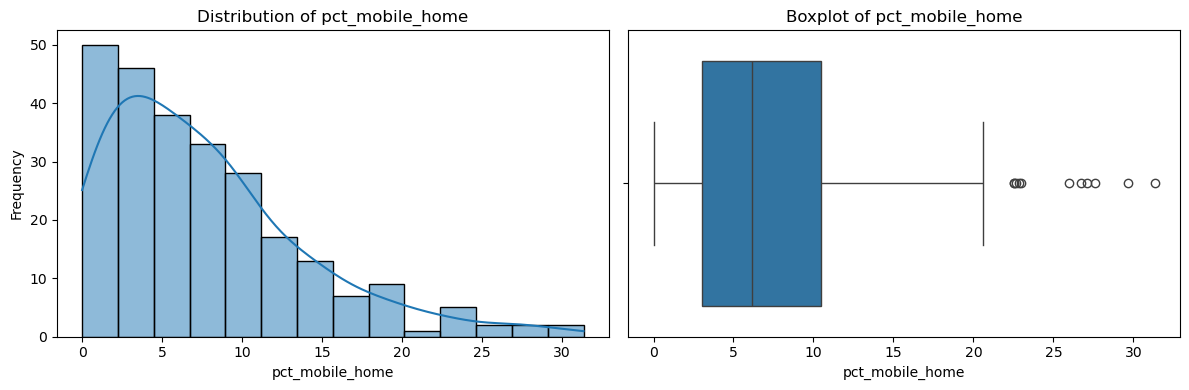

Skewness of pct_mobile_home: 1.2387401628357797


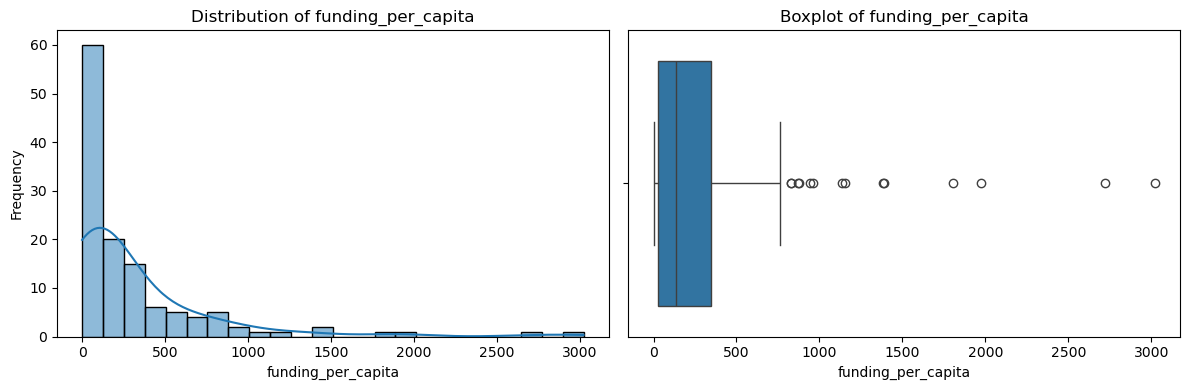

Skewness of funding_per_capita: 3.1243224313273177


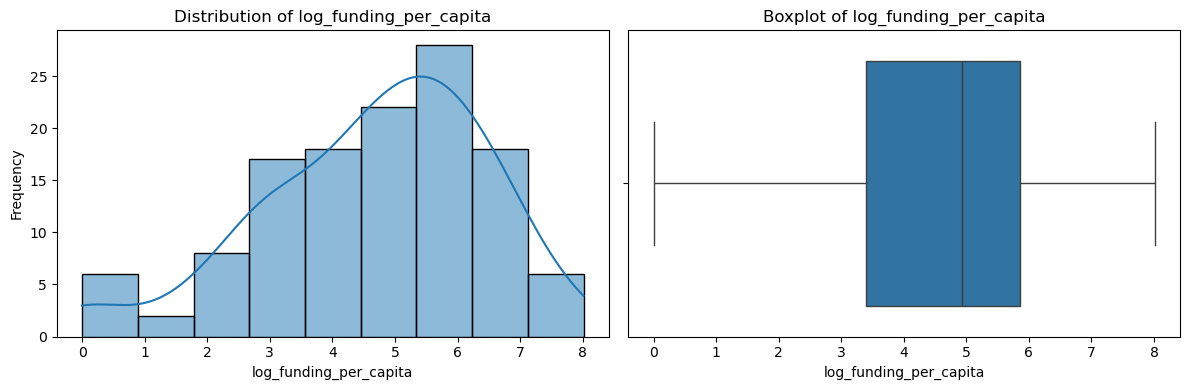

Skewness of log_funding_per_capita: -0.6751338787819535


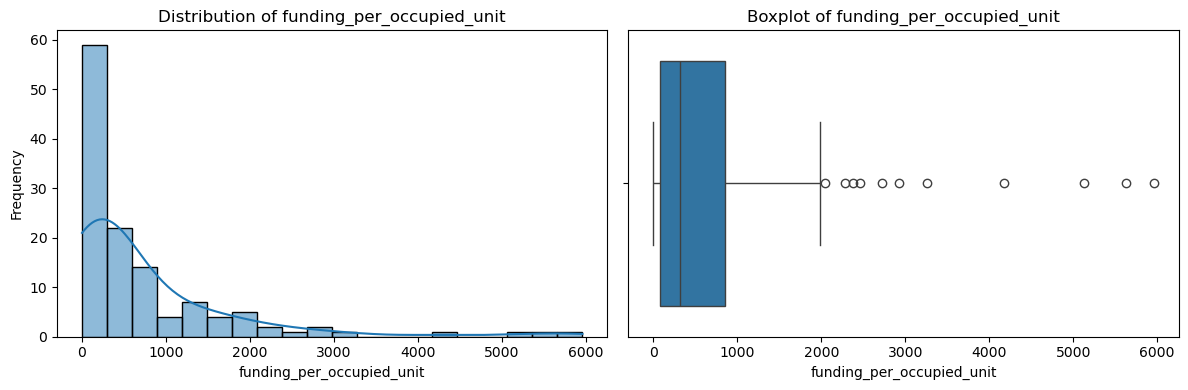

Skewness of funding_per_occupied_unit: 2.7916564280610525


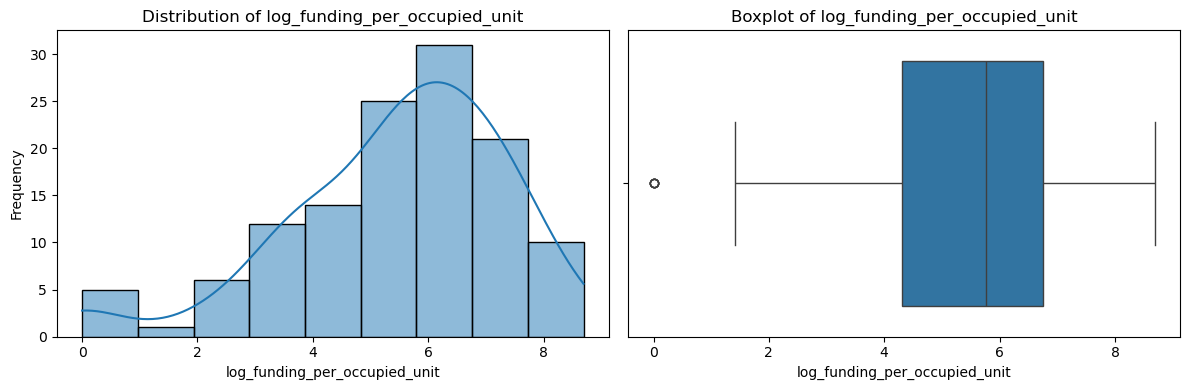

Skewness of log_funding_per_occupied_unit: -0.9492950893070283


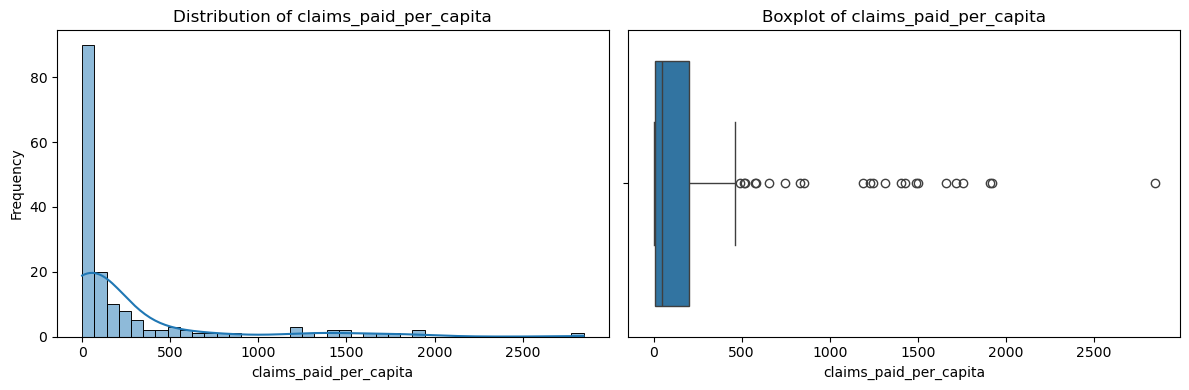

Skewness of claims_paid_per_capita: 2.8616138055659204


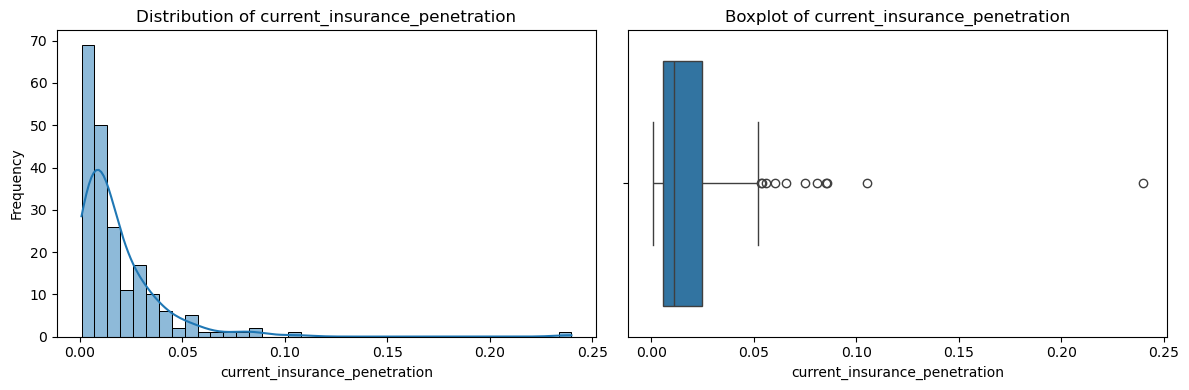

Skewness of current_insurance_penetration: 5.072012958443464


In [8]:
# in a 1x2 grid, plot histograms and boxplots for key variables
for var in key_vars:
    plt.figure(figsize=(12, 4))

    # histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

    # boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[var].dropna())
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)

    plt.tight_layout()
    plt.show()

    print(f"Skewness of {var}: {df[var].skew()}")

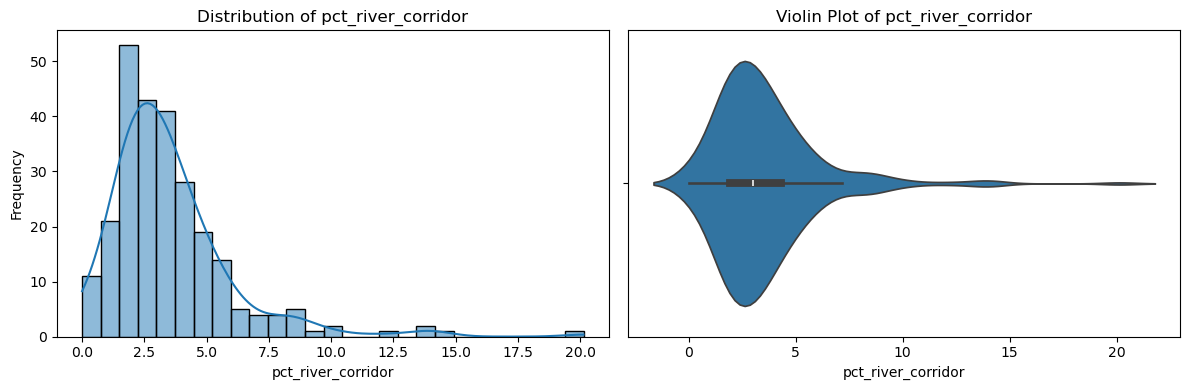

Skewness of pct_river_corridor: 2.4697920923443912


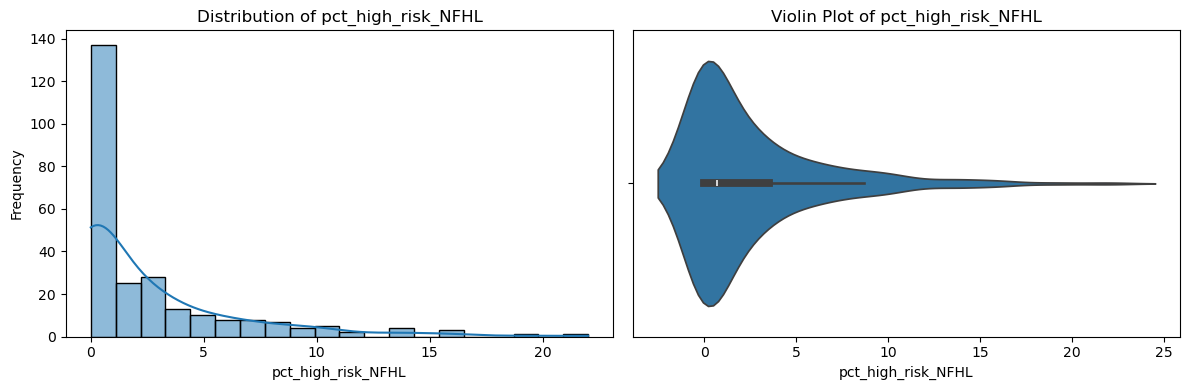

Skewness of pct_high_risk_NFHL: 2.119303961985999


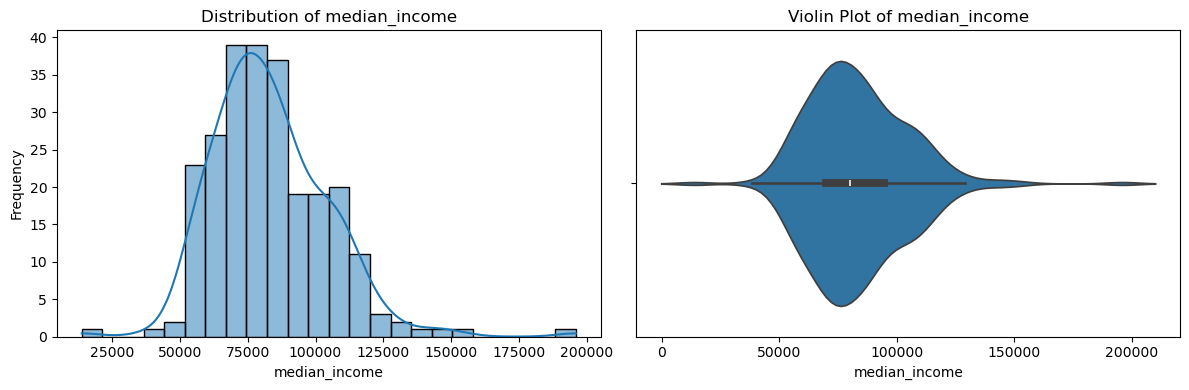

Skewness of median_income: 0.9243938865890698


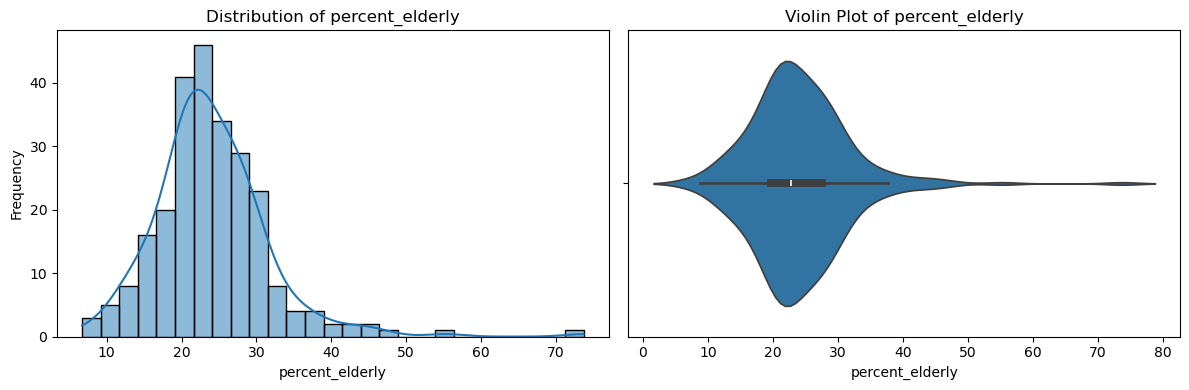

Skewness of percent_elderly: 1.6222988127759623


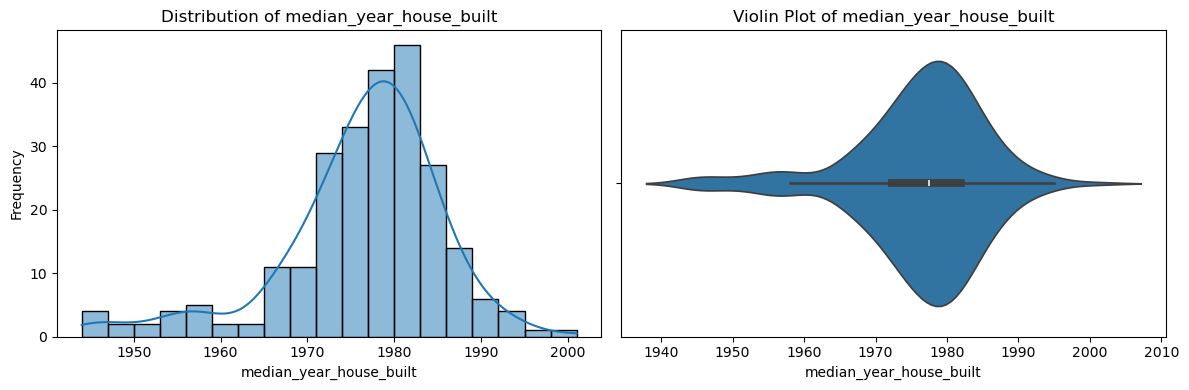

Skewness of median_year_house_built: -1.114547131355426


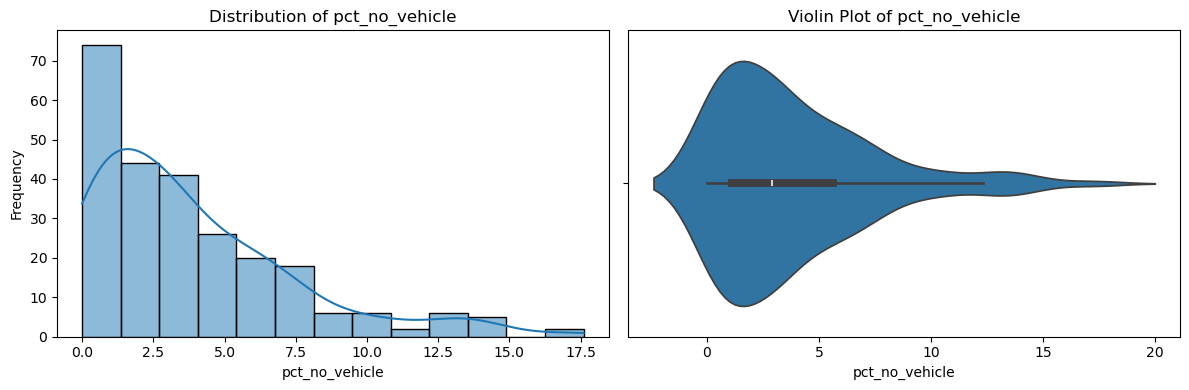

Skewness of pct_no_vehicle: 1.3964799861854658


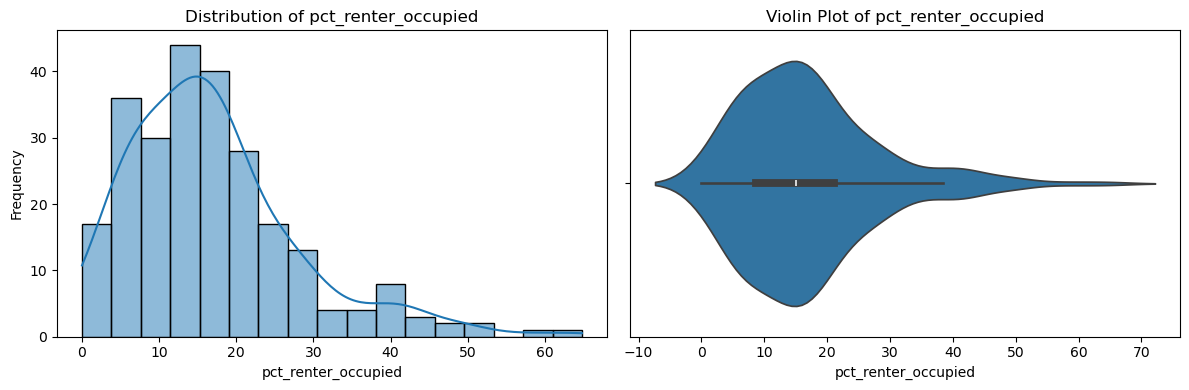

Skewness of pct_renter_occupied: 1.2528103476080978


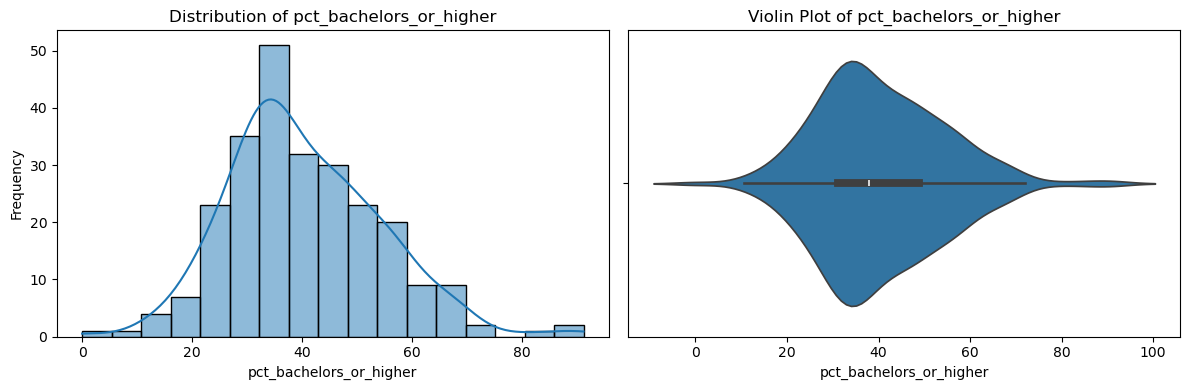

Skewness of pct_bachelors_or_higher: 0.5321044877100725


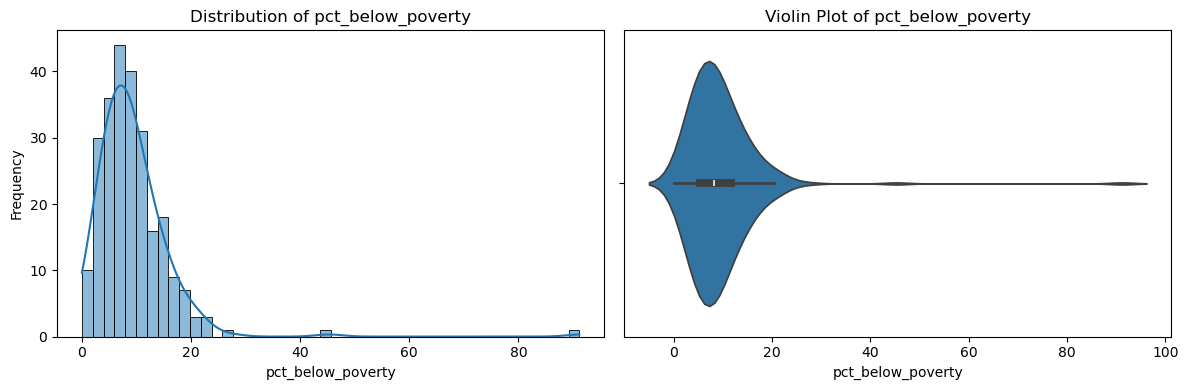

Skewness of pct_below_poverty: 5.775772763945157


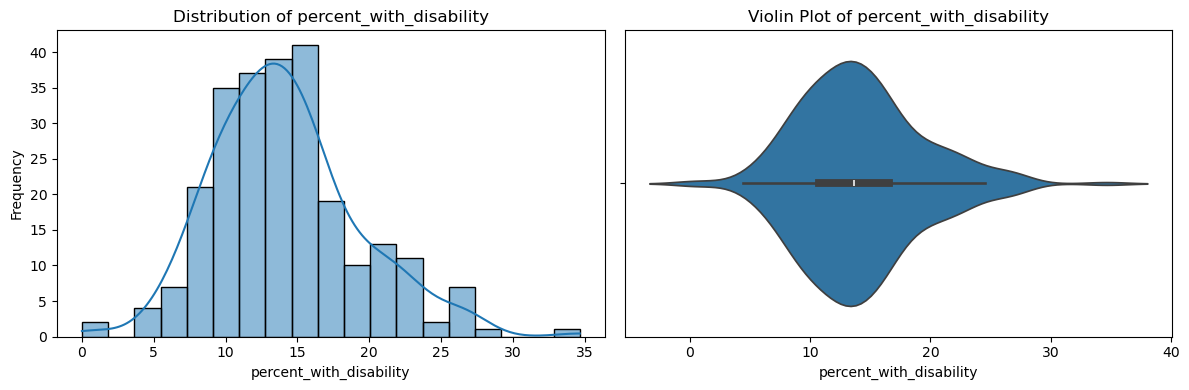

Skewness of percent_with_disability: 0.6194403059336864


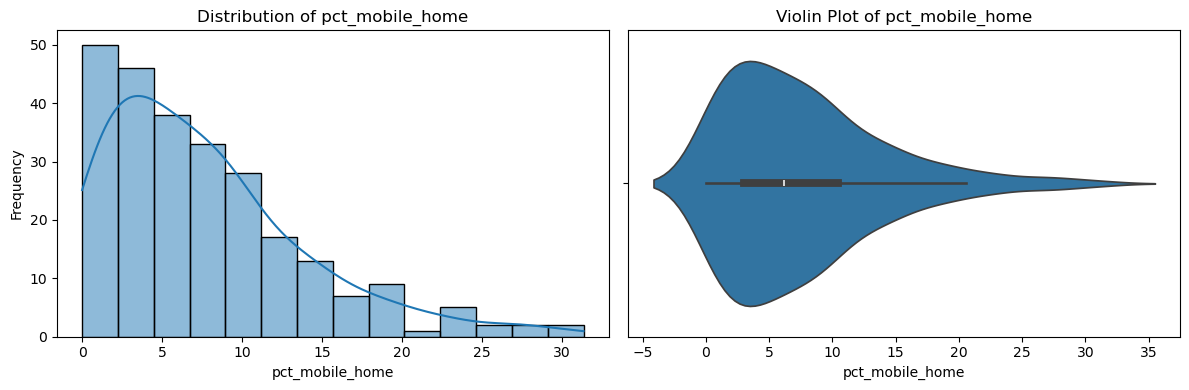

Skewness of pct_mobile_home: 1.2387401628357797


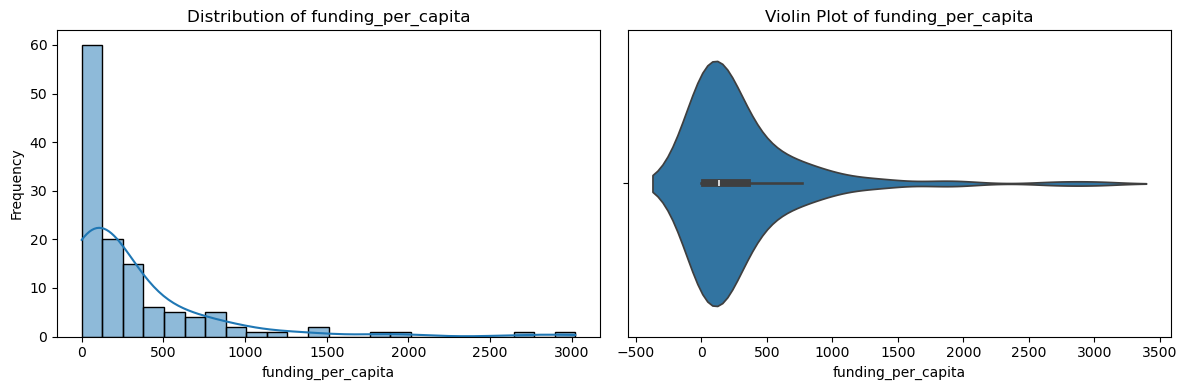

Skewness of funding_per_capita: 3.1243224313273177


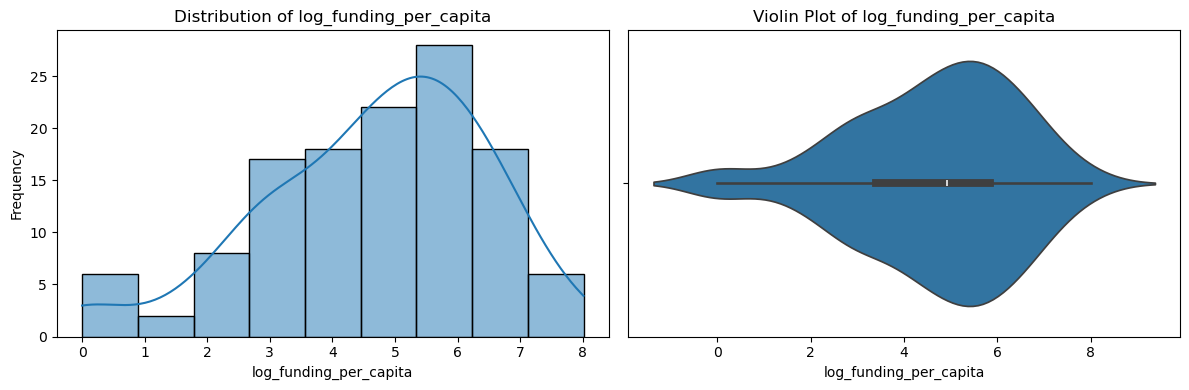

Skewness of log_funding_per_capita: -0.6751338787819535


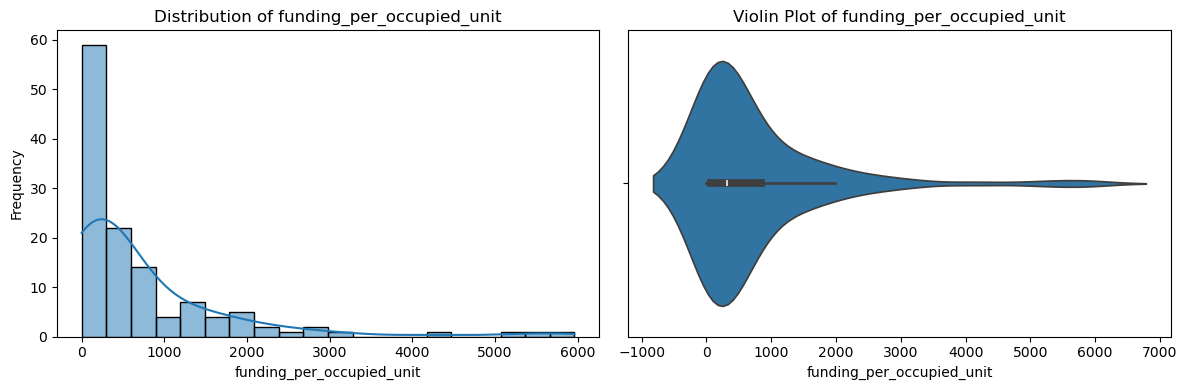

Skewness of funding_per_occupied_unit: 2.7916564280610525


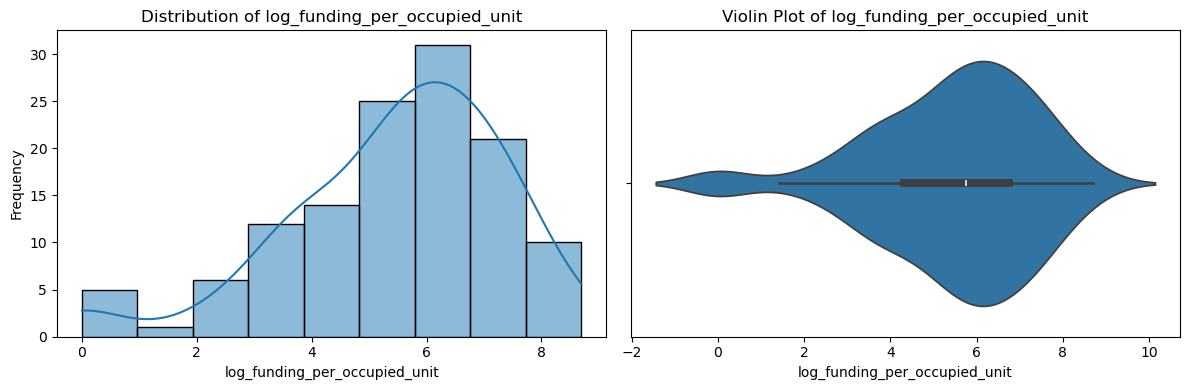

Skewness of log_funding_per_occupied_unit: -0.9492950893070283


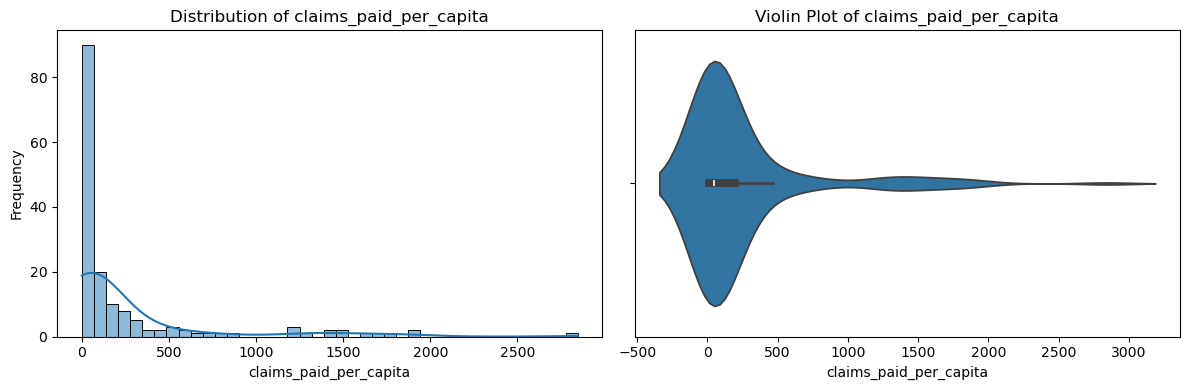

Skewness of claims_paid_per_capita: 2.8616138055659204


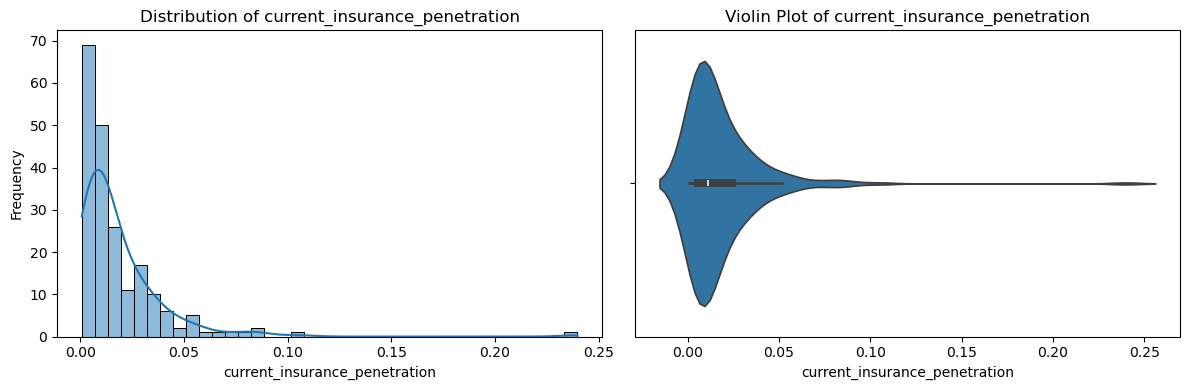

Skewness of current_insurance_penetration: 5.072012958443464


In [9]:
# in a 1x2 grid, plot histograms and violin plots for key variables
for var in key_vars:
    plt.figure(figsize=(12, 4))

    # histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

    # violin plot
    plt.subplot(1, 2, 2)
    sns.violinplot(x=df[var].dropna())
    plt.title(f"Violin Plot of {var}")
    plt.xlabel(var)

    plt.tight_layout()
    plt.show()

    print(f"Skewness of {var}: {df[var].skew()}")

In [10]:
# only print skewness for key variables
for var in key_vars:
    print(f"Skewness of {var}: {df[var].skew()}")

Skewness of pct_river_corridor: 2.4697920923443912
Skewness of pct_high_risk_NFHL: 2.119303961985999
Skewness of median_income: 0.9243938865890698
Skewness of percent_elderly: 1.6222988127759623
Skewness of median_year_house_built: -1.114547131355426
Skewness of pct_no_vehicle: 1.3964799861854658
Skewness of pct_renter_occupied: 1.2528103476080978
Skewness of pct_bachelors_or_higher: 0.5321044877100725
Skewness of pct_below_poverty: 5.775772763945157
Skewness of percent_with_disability: 0.6194403059336864
Skewness of pct_mobile_home: 1.2387401628357797
Skewness of funding_per_capita: 3.1243224313273177
Skewness of log_funding_per_capita: -0.6751338787819535
Skewness of funding_per_occupied_unit: 2.7916564280610525
Skewness of log_funding_per_occupied_unit: -0.9492950893070283
Skewness of claims_paid_per_capita: 2.8616138055659204
Skewness of current_insurance_penetration: 5.072012958443464


In [11]:
# pairplot for all key variables
# sns.pairplot(df[key_vars].dropna())

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


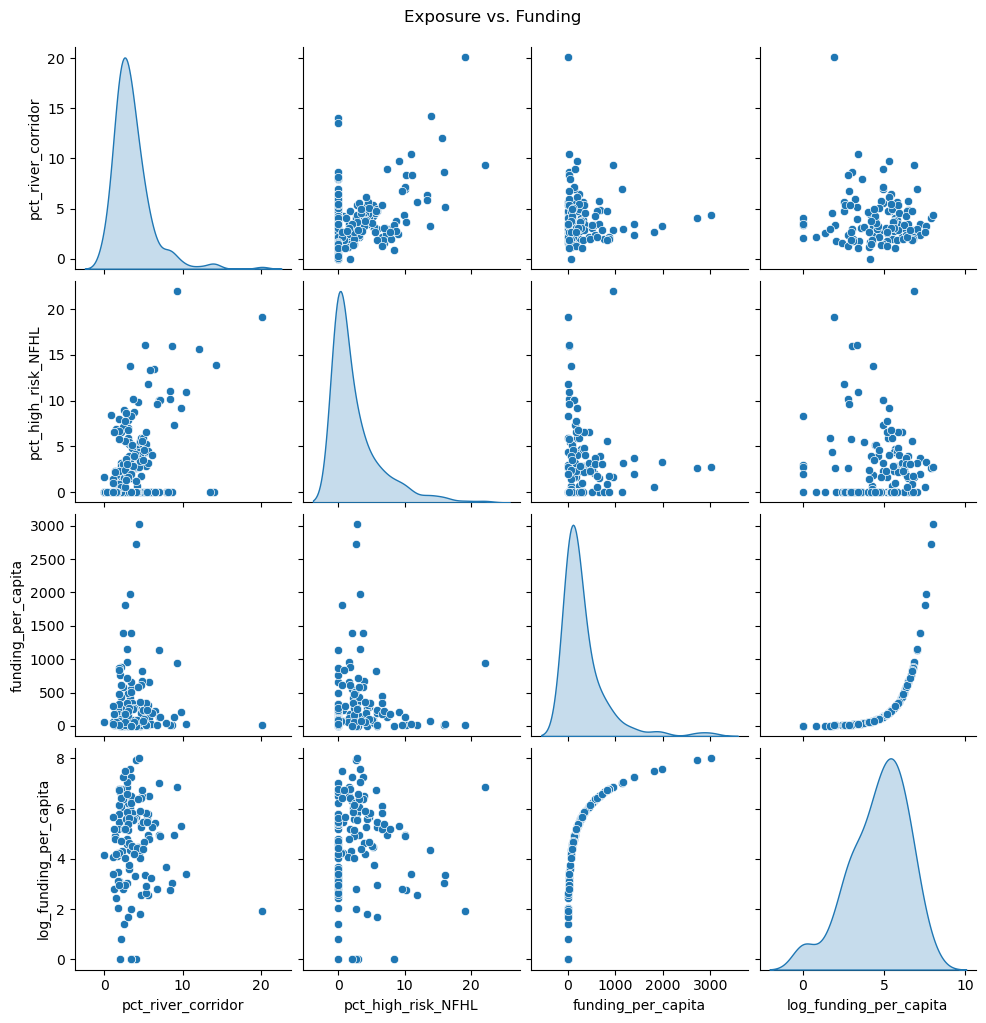

In [12]:
# exposure vs. funding pairplots
exposure_funding = [
    "pct_river_corridor",
    "pct_high_risk_NFHL",
    "funding_per_capita",
    "log_funding_per_capita",
]
sns.pairplot(df[exposure_funding], diag_kind="kde")
plt.suptitle("Exposure vs. Funding", y=1.02)
plt.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


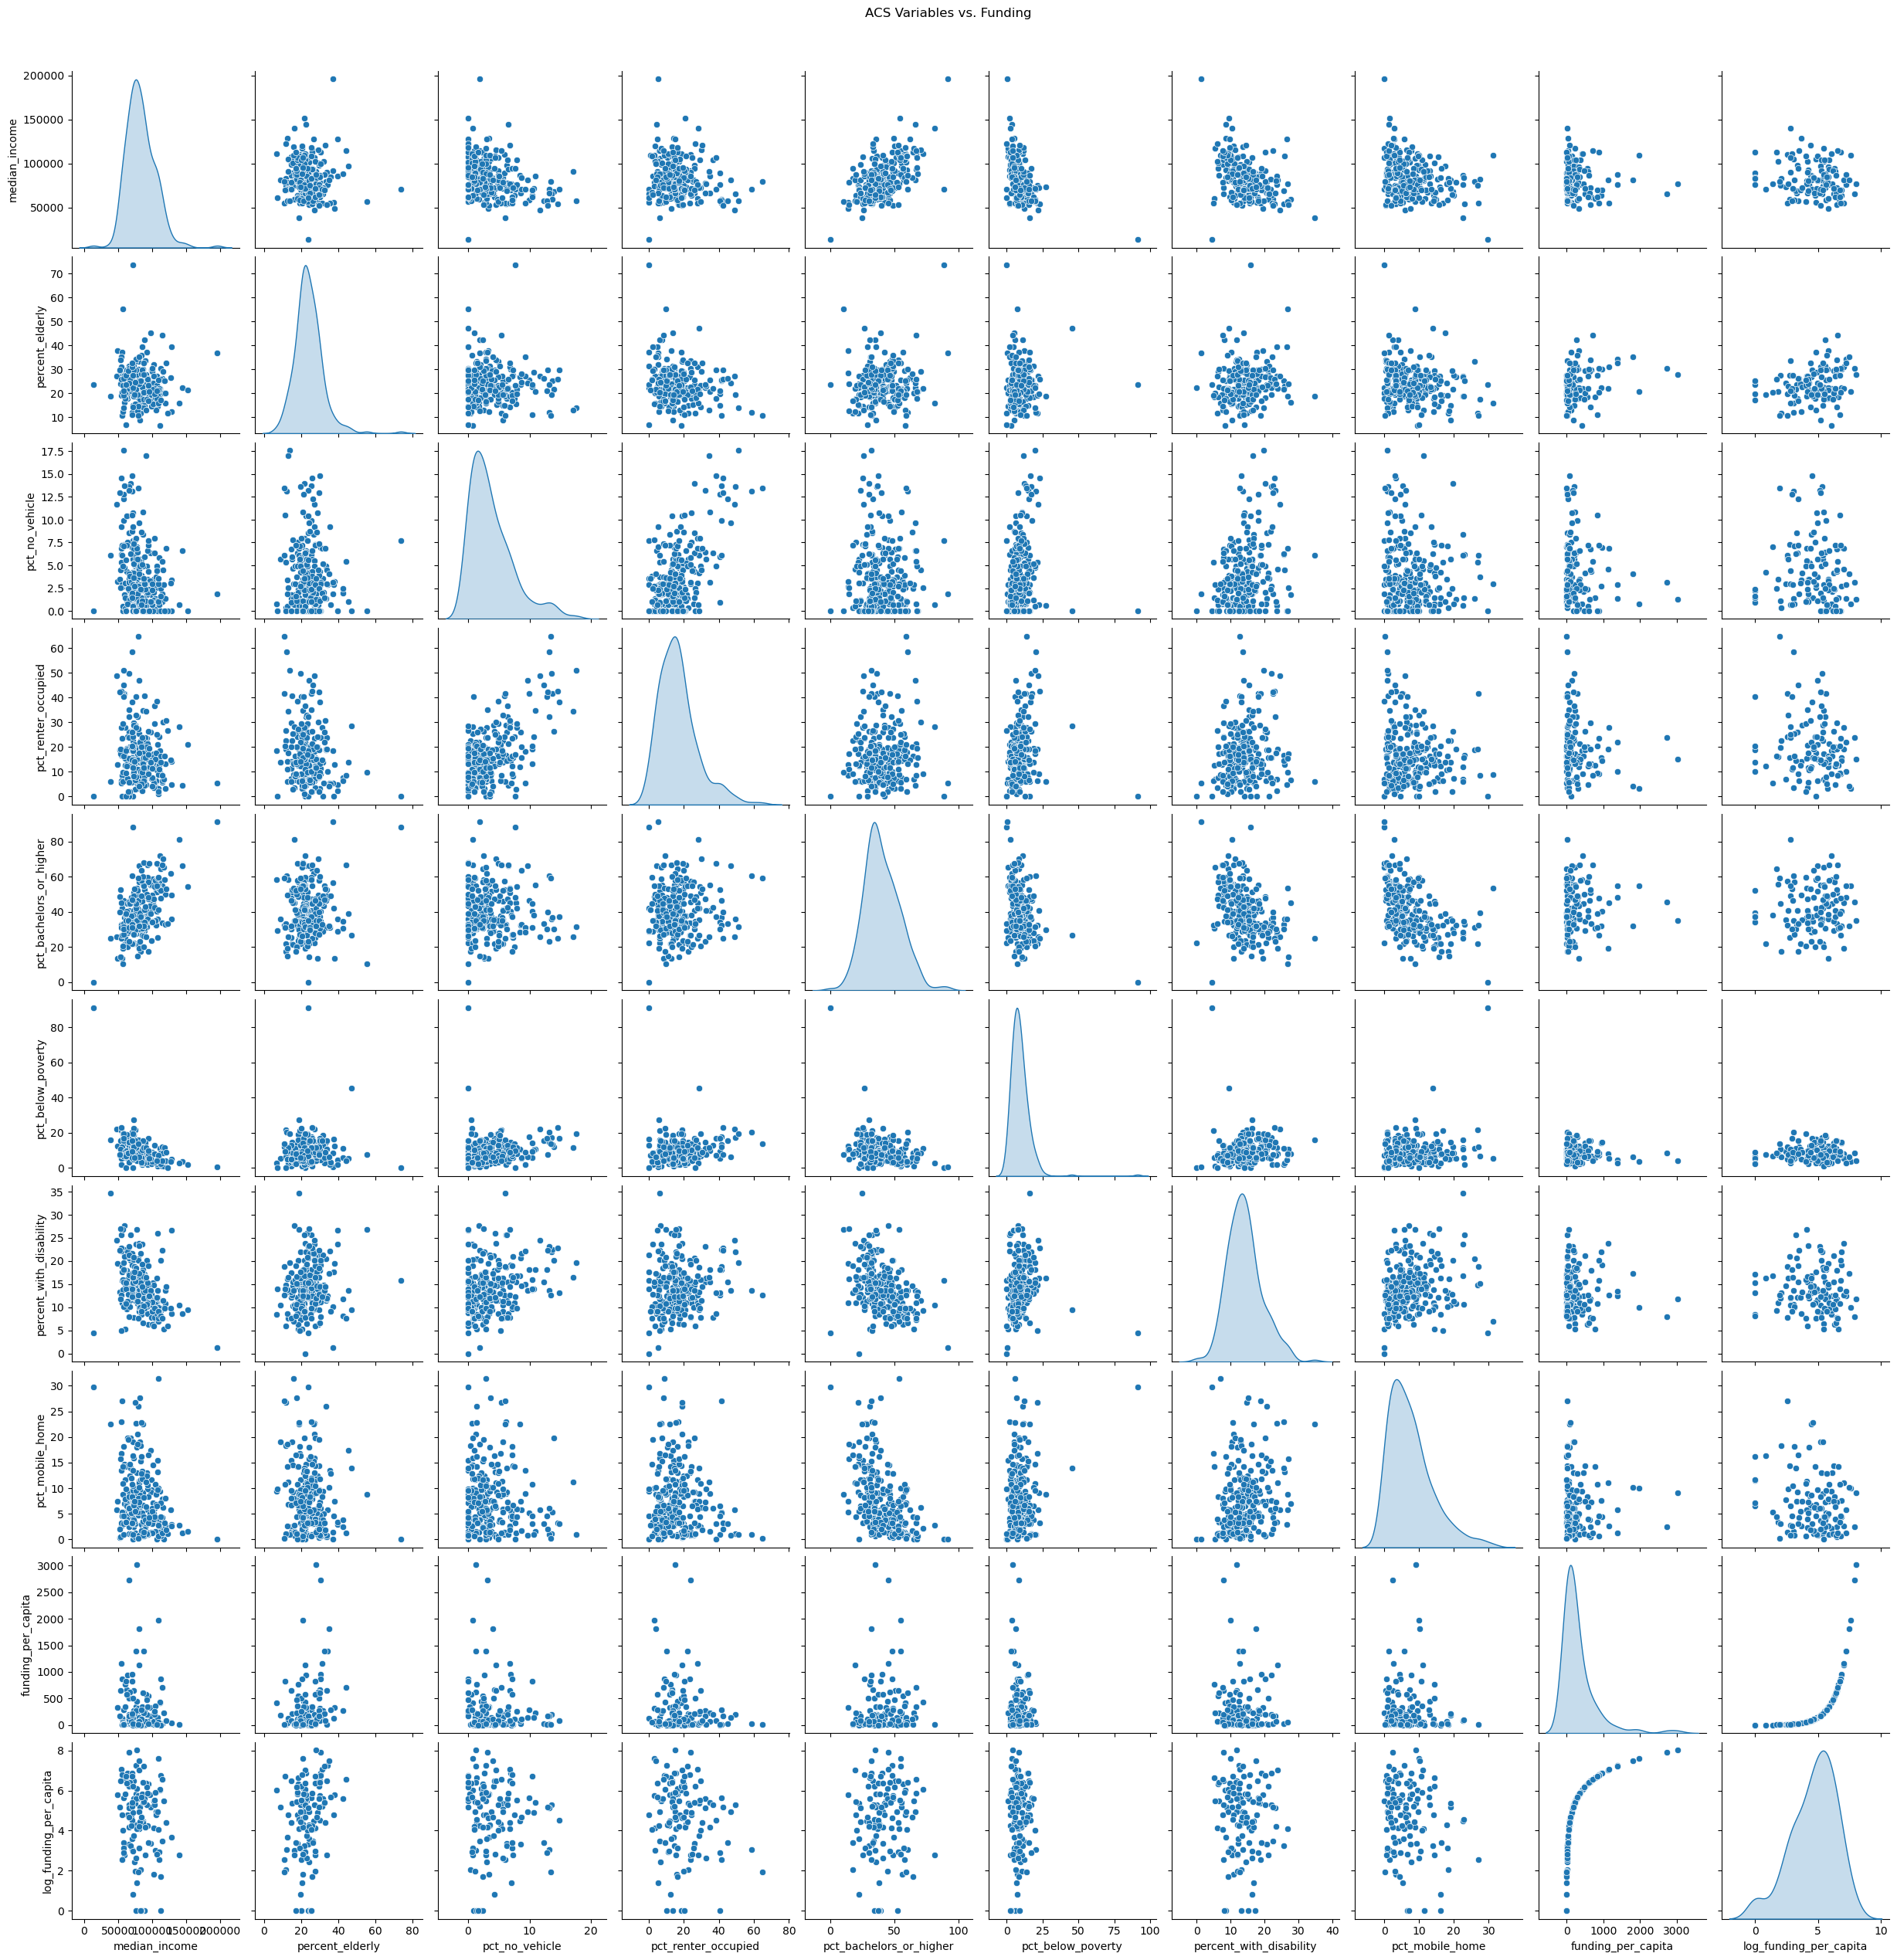

In [13]:
# acs variables vs. funding pairplots
acs_funding = [
    "median_income",
    "percent_elderly",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    "funding_per_capita",
    "log_funding_per_capita",
]
sns.pairplot(df[acs_funding], diag_kind="kde")
plt.suptitle("ACS Variables vs. Funding", y=1.02)
plt.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


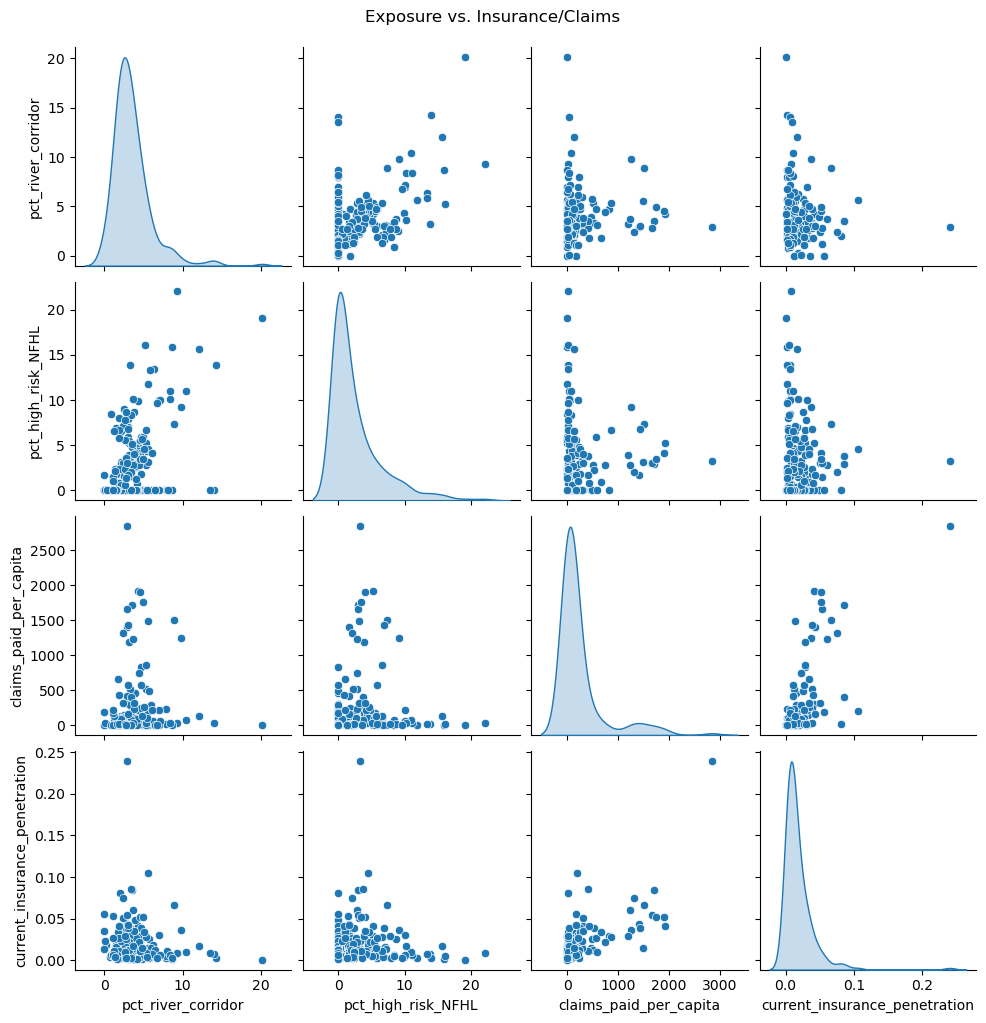

In [14]:
# exposure vs. insurance/claims pairplots
exposure_claims = [
    "pct_river_corridor",
    "pct_high_risk_NFHL",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]
sns.pairplot(df[exposure_claims], diag_kind="kde")
plt.suptitle("Exposure vs. Insurance/Claims", y=1.02)
plt.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


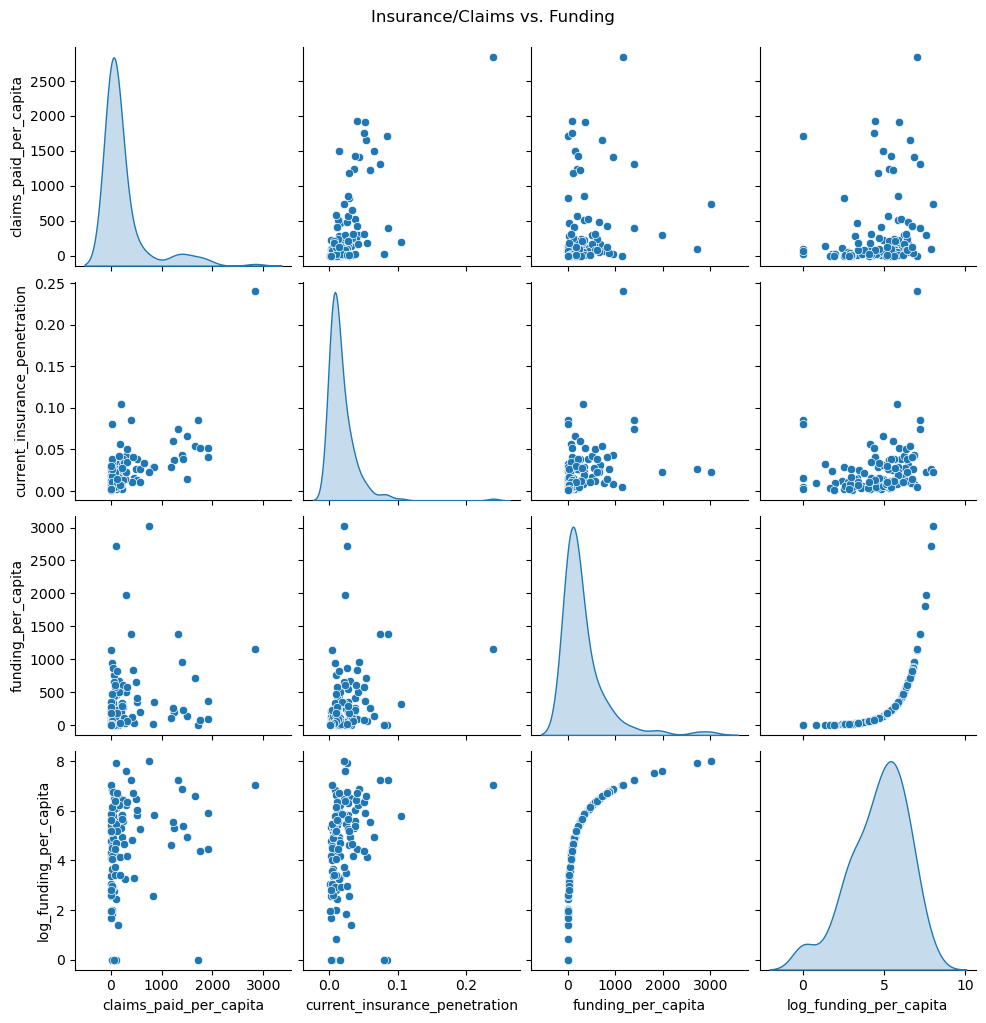

In [15]:
# insurance/claims vs. funding pairplots
insurance_claims = [
    "claims_paid_per_capita",
    "current_insurance_penetration",
    "funding_per_capita",
    "log_funding_per_capita",
]
sns.pairplot(df[insurance_claims], diag_kind="kde")
plt.suptitle("Insurance/Claims vs. Funding", y=1.02)
plt.show()

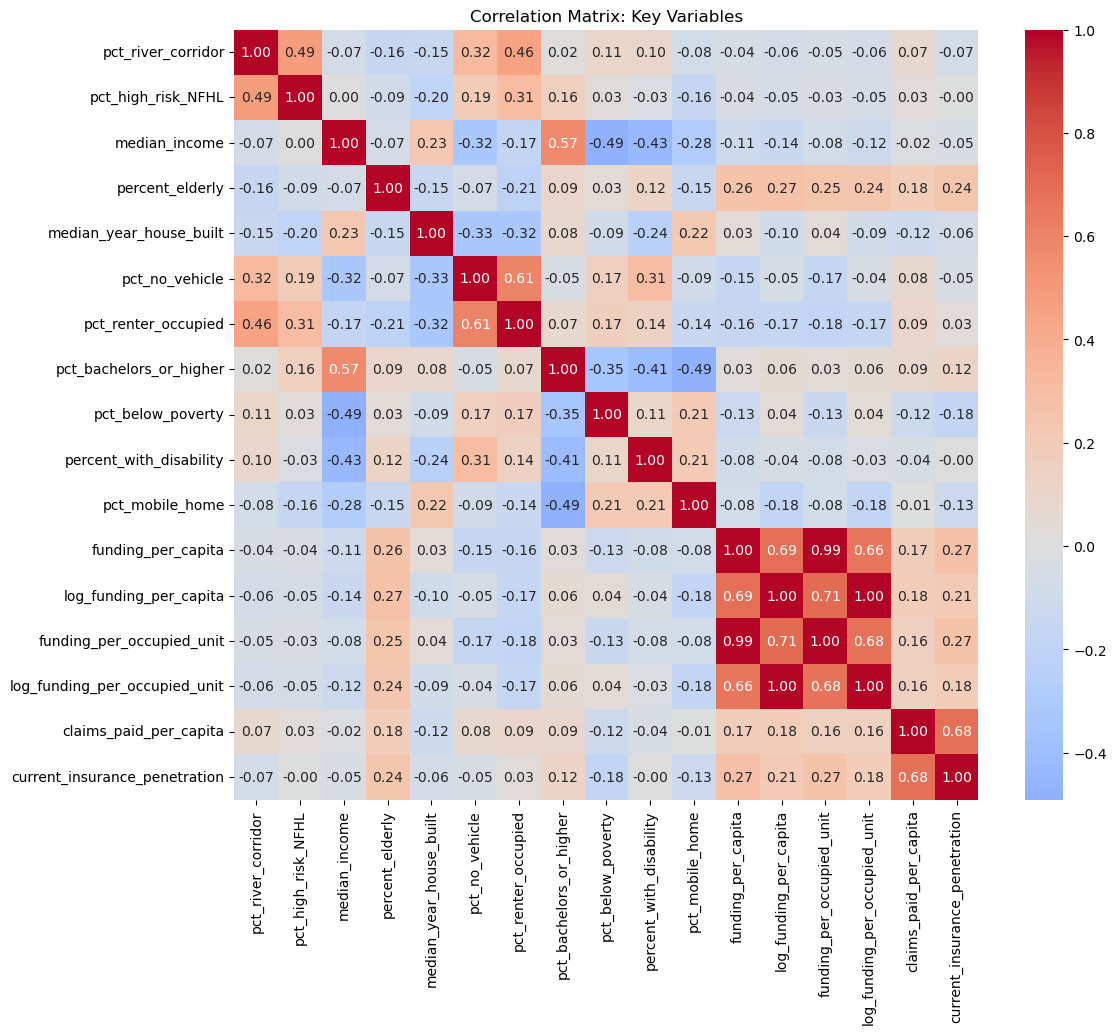

Correlation matrix:
                               pct_river_corridor  pct_high_risk_NFHL  \
pct_river_corridor                       1.000000            0.489341   
pct_high_risk_NFHL                       0.489341            1.000000   
median_income                           -0.065878            0.000210   
percent_elderly                         -0.156061           -0.085800   
median_year_house_built                 -0.151067           -0.199310   
pct_no_vehicle                           0.316051            0.193866   
pct_renter_occupied                      0.457435            0.310025   
pct_bachelors_or_higher                  0.015330            0.162426   
pct_below_poverty                        0.105314            0.025306   
percent_with_disability                  0.099392           -0.027806   
pct_mobile_home                         -0.079547           -0.161120   
funding_per_capita                      -0.038611           -0.036201   
log_funding_per_capita         

In [16]:
# correlation matrix for key variables
corr = df[key_vars].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Key Variables")
plt.show()

# print correlation matrix as text
print("Correlation matrix:")
print(corr)

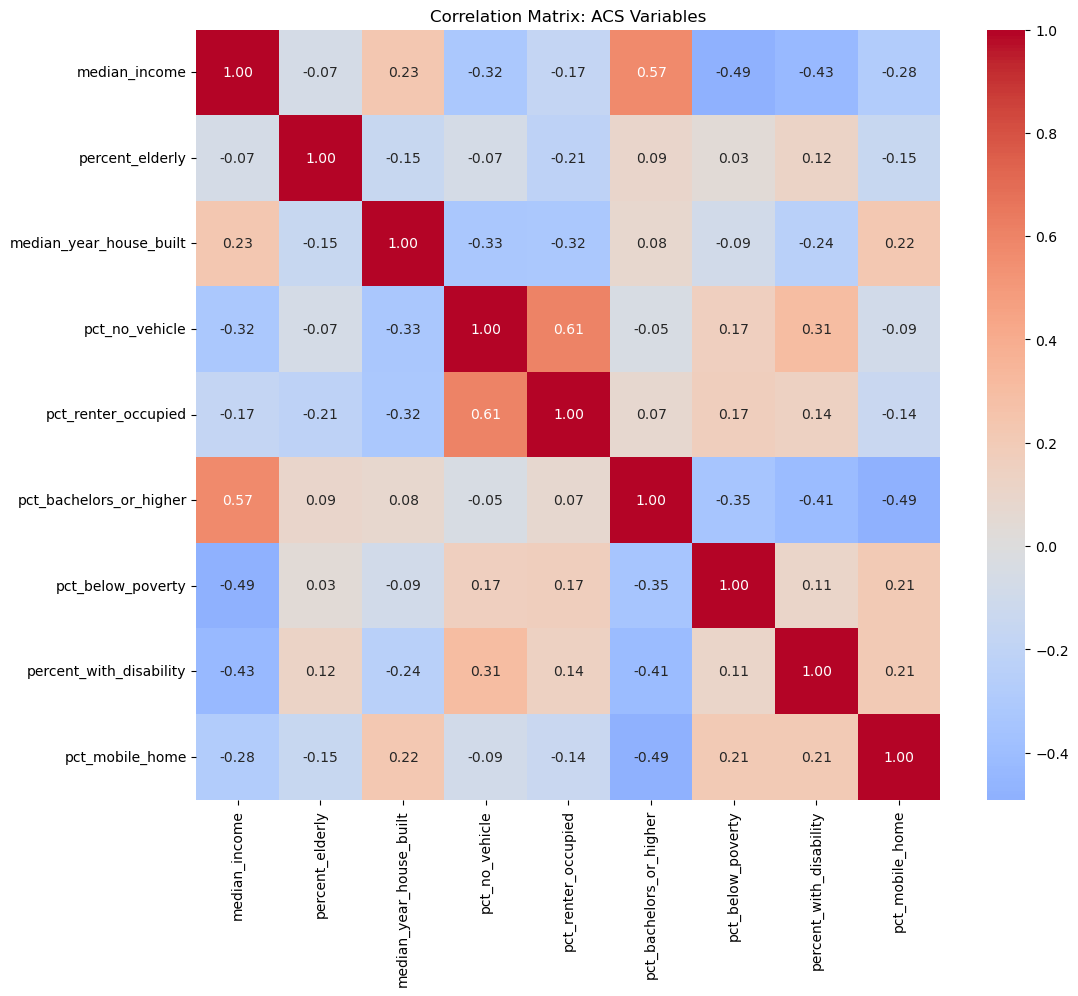

In [17]:
# correlation matrix just for acs variables
acs_vars = [
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
]
# correlation matrix for acs variables
corr = df[acs_vars].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: ACS Variables")
plt.show()